# 🏦 FinTech GraphRAG Pipeline — Sprint 1

> **Author:** Huzaifa Qureshi  
> **Goal:** Production-grade GraphRAG system for FinTech using Neo4j + Qdrant  
> **Stack:** Neo4j · Qdrant · Groq (LLaMA 3.3) · Instructor · Sentence-Transformers

---

## 📐 Architecture Overview

```
User Query
    │
    ▼
┌─────────────────┐
│  Query Router   │  ← LLM decides: LOCAL or GLOBAL
└────────┬────────┘
         │
   ┌─────┴──────┐
   │            │
   ▼            ▼
LOCAL         GLOBAL
   │            │
Qdrant      Qdrant
Entity      Summary
Search      Search
   │            │
Neo4j       Level 0/1
Subgraph    Community
   │        Summaries
   └─────┬──────┘
         │
    ┌────▼────┐
    │   LLM   │  ← Final Answer
    └─────────┘
```

---

## 📦 Table of Contents
1. [Installation](#1-installation)
2. [Imports & Configuration](#2-imports--configuration)
3. [Database Connections](#3-database-connections)
4. [Synthetic Data Generation](#4-synthetic-data-generation)
5. [Neo4j Ingestion](#5-neo4j-ingestion)
6. [Community Detection (Leiden)](#6-community-detection)
7. [Community Summarization](#7-community-summarization)
8. [Qdrant Ingestion](#8-qdrant-ingestion)
9. [RAG Pipeline — Retrieval & Generation](#9-rag-pipeline)
10. [Visualization](#10-visualization)

---
## 1. Installation
Install all required packages.

In [1]:
# Core dependencies
!pip install -q neo4j qdrant-client sentence-transformers
!pip install -q instructor groq openai
!pip install -q llama-index llama-index-llms-groq
!pip install -q pydantic

print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.4/177.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.8/358.8 kB 35.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## 2. Imports & Configuration
All imports and API key setup in one place.

In [2]:
# ─────────────────────────────────────────
# STANDARD LIBRARY
# ─────────────────────────────────────────
import os
import uuid
from typing import List, Dict, Optional
from collections import defaultdict

# ─────────────────────────────────────────
# DATA VALIDATION
# ─────────────────────────────────────────
from pydantic import BaseModel, Field

# ─────────────────────────────────────────
# GRAPH DATABASE
# ─────────────────────────────────────────
from neo4j import GraphDatabase

# ─────────────────────────────────────────
# VECTOR DATABASE
# ─────────────────────────────────────────
from qdrant_client import QdrantClient, models
from qdrant_client.models import PointStruct
from qdrant_client.http.models import PayloadSchemaType
from qdrant_client.http import models as rest

# ─────────────────────────────────────────
# LLM & STRUCTURED OUTPUT
# ─────────────────────────────────────────
import instructor
from groq import Groq as GroqClient
from llama_index.llms.groq import Groq as LlamaGroq

# ─────────────────────────────────────────
# EMBEDDINGS
# ─────────────────────────────────────────
from sentence_transformers import SentenceTransformer

# ─────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("✅ All imports successful!")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


✅ All imports successful!


In [ ]:
# ─────────────────────────────────────────
# ⚠️  CONFIGURATION — Replace with your keys
# ─────────────────────────────────────────

# Neo4j AuraDB
NEO4J_URI  = "bolt://YOUR_NEO4J_URI"      # e.g. bolt://3.95.28.198
NEO4J_USER = "neo4j"
NEO4J_PASS = "YOUR_NEO4J_PASSWORD"

# Qdrant Cloud
QDRANT_URL     = "YOUR_QDRANT_URL"
QDRANT_API_KEY = "YOUR_QDRANT_API_KEY"

# Groq API
GROQ_API_KEY = "YOUR_GROQ_API_KEY"

# Qdrant Collection Names
COLLECTION_ENTITIES  = "llm_entities"
COLLECTION_SUMMARIES = "llm_summaries"

# Embedding Model
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"  # 384 dimensions
EMBED_DIMENSION  = 384

# LLM Model
LLM_MODEL = "llama-3.3-70b-versatile"

print("✅ Configuration loaded!")

✅ Configuration loaded!


---
## 3. Database Connections
Connect to Neo4j and Qdrant.

In [4]:
class Neo4jGraph:
    """
    Neo4j database connection wrapper.
    Provides helper methods for running Cypher queries.
    """

    def __init__(self, uri: str, auth: tuple):
        self.driver = GraphDatabase.driver(uri, auth=auth)

    def close(self):
        """Close the database connection."""
        if self.driver:
            self.driver.close()

    def run_query(self, query: str, parameters: dict = None) -> list:
        """Execute a read query and return all records."""
        with self.driver.session() as session:
            result = session.run(query, parameters or {})
            return [record for record in result]

    def session(self):
        """Return a raw session for complex transactions."""
        return self.driver.session()

In [17]:
# ─── Neo4j Connection ───
try:
    db = Neo4jGraph(NEO4J_URI, (NEO4J_USER, NEO4J_PASS))
    driver = db.driver
    test = db.run_query("RETURN 'Neo4j Connected!' AS message")
    print(f"✅ {test[0]['message']}")
except Exception as e:
    print(f"❌ Neo4j Connection Failed: {e}")

# ─── Qdrant Connection ───
try:
    qdrant_client = QdrantClient(url=QDRANT_URL, api_key=QDRANT_API_KEY)
    collections = qdrant_client.get_collections()
    print(f"✅ Qdrant Connected! Collections: {[c.name for c in collections.collections]}")
except Exception as e:
    print(f"❌ Qdrant Connection Failed: {e}")

# ─── LLM Setup ───
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
llm       = LlamaGroq(model=LLM_MODEL)
groq_raw  = GroqClient(api_key=GROQ_API_KEY)
groq_instructor = instructor.patch(groq_raw, mode=instructor.Mode.JSON)
print(f"✅ LLM Ready: {LLM_MODEL}")

# ─── Embedding Model ───
embed_model = SentenceTransformer(EMBED_MODEL_NAME)
print(f"✅ Embedding Model Ready: {EMBED_MODEL_NAME} (dim={EMBED_DIMENSION})")

✅ Neo4j Connected!
✅ Qdrant Connected! Collections: ['summaries_with_new', 'chunk_text', 'summaries', 'newstore', 'graph_collection', 'vector rag', 'graphRAGstoreds', 'llm_summaries', 'schema_save', 'llm_summaries_new', 'vector rag_for', 'llm_entities', 'vector rag_ths', 'schema_text', 'vector rag_this', 'community_name_collection']
✅ LLM Ready: llama-3.3-70b-versatile
✅ Embedding Model Ready: all-MiniLM-L6-v2 (dim=384)


---
## 4. Synthetic Data Generation
Generate 40 FinTech companies with relationships using LLM + Instructor.

In [6]:
# ─────────────────────────────────────────
# PYDANTIC SCHEMAS FOR STRUCTURED OUTPUT
# ─────────────────────────────────────────

class CompaniesList(BaseModel):
    """Schema for extracting company names and sectors."""
    companies: List[str] = Field(description="List of unique company names")
    sectors:   List[str] = Field(description="Corresponding sector for each company")


class CompanyDetails(BaseModel):
    """Detailed profile for a single FinTech company."""
    company_name:           str        = Field(description="Company name")
    sector:                 str        = Field(description="Industry sector")
    ceo:                    str        = Field(description="Current CEO full name")
    ceo_previous_companies: List[str]  = Field(description="Companies where CEO worked before")
    ceo_previous_positions: List[str]  = Field(description="Positions CEO held previously")
    profit_loss:            float      = Field(description="Profit (+) or loss (-) in millions USD")
    connected_companies:    List[str]  = Field(description="Other companies this one is connected to")
    impact_percentage:      List[float]= Field(description="Impact % on each connected company")
    relationship_type:      List[str]  = Field(description="Type of relationship e.g. PARTNER, COMPETITOR")


class CEOHistory(BaseModel):
    """CEO career history for building person nodes."""
    ceo_name:          str       = Field(description="Full CEO name")
    current_company:   str       = Field(description="Current company")
    current_position:  str       = Field(description="Current title e.g. CEO")
    previous_roles:    List[str] = Field(description="Previous positions e.g. CFO at Company X")
    years_experience:  int       = Field(description="Total years of experience")

In [7]:
def call_llm(prompt: str) -> str:
    """Simple LLM call using LlamaIndex Groq wrapper."""
    response = llm.complete(prompt)
    return response.text


def generate_companies_list(n: int = 40) -> CompaniesList:
    """
    Step 1: Generate N FinTech company names and their sectors.

    Args:
        n: Number of companies to generate

    Returns:
        CompaniesList with names and sectors
    """
    return groq_instructor.chat.completions.create(
        response_model=CompaniesList,
        model=LLM_MODEL,
        messages=[{
            "role": "user",
            "content": (
                f"Generate {n} unique fictional FinTech company names across diverse sectors "
                "(Payments, Banking, Insurance, Lending, Crypto, FMCG, Telecom). "
                "Return exactly matching companies and sectors lists."
            )
        }]
    )


def generate_company_details(batch: List[str], sectors: List[str]) -> List[CompanyDetails]:
    """
    Step 2: Generate detailed profiles for a batch of companies.

    Args:
        batch:   List of company names
        sectors: Corresponding sectors

    Returns:
        List of CompanyDetails
    """
    details = []
    for company, sector in zip(batch, sectors):
        try:
            detail = groq_instructor.chat.completions.create(
                response_model=CompanyDetails,
                model=LLM_MODEL,
                messages=[{
                    "role": "user",
                    "content": (
                        f"Generate a realistic FinTech company profile for '{company}' in the '{sector}' sector. "
                        "Include CEO background, financial performance, and 3-5 business relationships with impact percentages."
                    )
                }]
            )
            details.append(detail)
            print(f"  ✅ Generated: {company}")
        except Exception as e:
            print(f"  ❌ Failed: {company} — {e}")
    return details

In [8]:
# ─── Run Data Generation ───
print("🔄 Step 1: Generating company names...")
companies_list = generate_companies_list(n=40)
print(f"✅ Generated {len(companies_list.companies)} companies")

print("\n🔄 Step 2: Generating company details (batches of 5)...")
all_companies = []
batch_size = 5

for i in range(0, len(companies_list.companies), batch_size):
    batch_names   = companies_list.companies[i:i+batch_size]
    batch_sectors = companies_list.sectors[i:i+batch_size]
    print(f"\n  Batch {i//batch_size + 1}: {batch_names}")
    batch_details = generate_company_details(batch_names, batch_sectors)
    all_companies.extend(batch_details)

print(f"\n✅ Total Companies Generated: {len(all_companies)}")

🔄 Step 1: Generating company names...
✅ Generated 37 companies

🔄 Step 2: Generating company details (batches of 5)...

  Batch 1: ['PayPlex', 'BankGenie', 'InsureSmart', 'LendPal', 'CryptoZone']
  ✅ Generated: PayPlex
  ✅ Generated: BankGenie
  ✅ Generated: InsureSmart
  ✅ Generated: LendPal
  ✅ Generated: CryptoZone

  Batch 2: ['EasyPay', 'TeleCash', 'MoneyMall', 'FinServe', 'PayMax']
  ✅ Generated: EasyPay
  ✅ Generated: TeleCash
  ✅ Generated: MoneyMall
  ✅ Generated: FinServe
  ✅ Generated: PayMax

  Batch 3: ['BankBridge', 'SecureInsure', 'LoanLane', 'CoinCraft', 'QuickTel']
  ✅ Generated: BankBridge
  ✅ Generated: SecureInsure
  ✅ Generated: LoanLane
  ✅ Generated: CoinCraft
  ✅ Generated: QuickTel

  Batch 4: ['SmartSpend', 'CashClub', 'BankBuddy', 'FinSafe', 'PayPro']
  ✅ Generated: SmartSpend
  ✅ Generated: CashClub
  ✅ Generated: BankBuddy
  ✅ Generated: FinSafe
  ✅ Generated: PayPro

  Batch 5: ['TeleMoney', 'FastPay', 'EzyLend', 'CryptoHub', 'PennyPay']
  ✅ Generated: Tel

---
## 5. Neo4j Ingestion
Convert generated data into graph nodes and relationships, then push to Neo4j.

In [9]:
# ─────────────────────────────────────────
# GRAPH NODE & RELATIONSHIP SCHEMAS
# ─────────────────────────────────────────

class GraphNode(BaseModel):
    """Represents a node to be inserted into Neo4j."""
    id:         str  = Field(default_factory=lambda: str(uuid.uuid4()), exclude=True)
    name:       str
    label:      str  # 'Company' or 'CEO'
    properties: Dict = Field(default_factory=dict)

    @property
    def uid(self) -> str:
        return self.id


class GraphRelationship(BaseModel):
    """Represents a relationship between two Neo4j nodes."""
    source_id:         str
    target_id:         str
    relationship_type: str
    impact_percentage: float = 0.0

In [10]:
def build_graph_objects(companies: list) -> tuple:
    """
    Convert CompanyDetails list into graph nodes and relationships.

    Args:
        companies: List of CompanyDetails

    Returns:
        Tuple of (nodes_dict, relationships_list)
        nodes_dict: {name -> {uid, name, label, properties}}
    """
    nodes: Dict[str, dict]    = {}
    relationships: List[dict] = []

    for company in companies:
        # ── Company Node ──
        company_uid = str(uuid.uuid4())
        nodes[company.company_name] = {
            "uid":   company_uid,
            "name":  company.company_name,
            "label": "Company",
            "properties": {
                "sector":      company.sector,
                "profit_loss": company.profit_loss
            }
        }

        # ── CEO Node ──
        ceo_uid = str(uuid.uuid4())
        nodes[company.ceo] = {
            "uid":   ceo_uid,
            "name":  company.ceo,
            "label": "CEO",
            "properties": {
                "previous_companies": company.ceo_previous_companies
            }
        }

        # ── CEO → Company Relationship ──
        relationships.append({
            "source_name": company.ceo,
            "target_name": company.company_name,
            "type":        "CEO_OF",
            "impact":      0.0
        })

        # ── Company → Company Relationships ──
        for connected, impact, rel_type in zip(
            company.connected_companies,
            company.impact_percentage,
            company.relationship_type
        ):
            if connected not in nodes:
                nodes[connected] = {
                    "uid":        str(uuid.uuid4()),
                    "name":       connected,
                    "label":      "Company",
                    "properties": {}
                }
            relationships.append({
                "source_name": company.company_name,
                "target_name": connected,
                "type":        rel_type.upper().replace(" ", "_"),
                "impact":      impact
            })

    print(f"✅ Built {len(nodes)} nodes and {len(relationships)} relationships")
    return nodes, relationships


def ingest_to_neo4j(all_nodes: dict, all_rels: list, graph_db: Neo4jGraph):
    """
    Push all nodes and relationships into Neo4j using MERGE (upsert).
    MERGE ensures no duplicates on re-run.

    Args:
        all_nodes: Dict of node data keyed by name
        all_rels:  List of relationship dicts
        graph_db:  Neo4jGraph instance
    """
    with graph_db.session() as session:

        # ── 1. Push Company Nodes ──
        companies = [n for n in all_nodes.values() if n['label'].lower() == 'company']
        session.run("""
            UNWIND $batch AS row
            MERGE (n:Company {id: row.uid})
            SET n.name          = row.name,
                n.sector        = row.properties.sector,
                n.profit_loss   = row.properties.profit_loss
        """, batch=companies)
        print(f"  ✅ Pushed {len(companies)} Company nodes")

        # ── 2. Push CEO Nodes ──
        ceos = [n for n in all_nodes.values() if n['label'].lower() == 'ceo']
        session.run("""
            UNWIND $batch AS row
            MERGE (n:CEO {id: row.uid})
            SET n.name = row.name
        """, batch=ceos)
        print(f"  ✅ Pushed {len(ceos)} CEO nodes")

        # ── 3. Push Relationships ──
        for rel in all_rels:
            source = all_nodes.get(rel['source_name'])
            target = all_nodes.get(rel['target_name'])
            if not source or not target:
                continue
            session.run(f"""
                MATCH (a {{id: $source_id}})
                MATCH (b {{id: $target_id}})
                MERGE (a)-[r:{rel['type']}]->(b)
                SET r.impact_percentage = $impact
            """,
            source_id=source['uid'],
            target_id=target['uid'],
            impact=rel['impact'])

        print(f"  ✅ Pushed {len(all_rels)} relationships")
    print("\n🎉 Neo4j ingestion complete!")

In [11]:
# ─── Run Neo4j Ingestion ───
print("🔄 Building graph objects...")
all_nodes, all_rels = build_graph_objects(all_companies)

print("\n🔄 Pushing to Neo4j...")
ingest_to_neo4j(all_nodes, all_rels, db)

# Verify
node_count = db.run_query("MATCH (n) RETURN count(n) AS total")
rel_count  = db.run_query("MATCH ()-[r]->() RETURN count(r) AS total")
print(f"\n📊 Neo4j Stats:")
print(f"   Nodes:         {node_count[0]['total']}")
print(f"   Relationships: {rel_count[0]['total']}")

🔄 Building graph objects...
✅ Built 126 nodes and 167 relationships

🔄 Pushing to Neo4j...
  ✅ Pushed 108 Company nodes
  ✅ Pushed 18 CEO nodes
  ✅ Pushed 167 relationships

🎉 Neo4j ingestion complete!

📊 Neo4j Stats:
   Nodes:         271
   Relationships: 390


---
## 6. Community Detection
Run Leiden algorithm via Neo4j GDS to detect communities at multiple levels.

In [12]:
def run_community_detection(graph_db: Neo4jGraph):
    """
    Run Leiden community detection algorithm using Neo4j GDS.

    Leiden is run with includeIntermediateCommunities=True to get
    hierarchical community levels:
      - Level 0: Fine-grained clusters (specific companies)
      - Level 1: Strategic groups (sector-level)

    NOTE: includeIntermediateCommunities must be True to avoid
    a known NullPointerException bug in Neo4j GDS Leiden.
    """

    # ── Step 1: Drop existing projection if any ──
    graph_db.run_query("CALL gds.graph.drop('finance_projection', false)")
    print("  🗑️  Dropped old projection (if existed)")

    # ── Step 2: Create new graph projection ──
    graph_db.run_query("""
        CALL gds.graph.project(
            'finance_projection',
            ['Company', 'CEO'],
            {
                ALL: {
                    type: '*',
                    orientation: 'UNDIRECTED',
                    properties: {
                        impact_percentage: {
                            property: 'impact_percentage',
                            defaultValue: 1.0
                        }
                    }
                }
            }
        )
    """)
    print("  ✅ Graph projection created")

    # ── Step 3: Run Leiden Algorithm ──
    # includeIntermediateCommunities=True is REQUIRED to avoid
    # NullPointerException in Neo4j GDS Leiden implementation.
    graph_db.run_query("""
        CALL gds.leiden.write(
            'finance_projection',
            {
                writeProperty: 'community',
                includeIntermediateCommunities: true,
                relationshipWeightProperty: 'impact_percentage',
                maxLevels: 3,
                gamma: 1.0,
                theta: 0.01
            }
        )
    """)
    print("  ✅ Leiden algorithm complete")

    # ── Step 4: Verify community assignment ──
    stats = graph_db.run_query("""
        MATCH (n)
        WHERE n.community IS NOT NULL
        RETURN size(n.community) AS levels, count(n) AS nodes
        LIMIT 1
    """)
    if stats:
        print(f"  📊 Community levels: {stats[0]['levels']}, Nodes assigned: {stats[0]['nodes']}")

    print("\n🎉 Community detection complete!")

In [13]:
print("🔄 Running Community Detection (Leiden Algorithm)...")
run_community_detection(db)

# ─── Inspect Communities ───
communities = db.run_query("""
    MATCH (n)
    WHERE (n:Company OR n:CEO) AND n.community IS NOT NULL
    RETURN DISTINCT n.community[0] AS level_0_id,
                    collect(n.name)[0..5] AS sample_nodes,
                    count(n) AS node_count
    ORDER BY node_count DESC
    LIMIT 10
""")

print("\n📊 Top 10 Communities (Level 0):")
print(f"{'Community ID':<15} {'Size':<8} {'Sample Nodes'}")
print("-" * 60)
for c in communities:
    print(f"{str(c['level_0_id']):<15} {c['node_count']:<8} {', '.join(c['sample_nodes'])}")

🔄 Running Community Detection (Leiden Algorithm)...


  🗑️  Dropped old projection (if existed)
  ✅ Graph projection created
  ✅ Leiden algorithm complete
  📊 Community levels: 2, Nodes assigned: 271

🎉 Community detection complete!

📊 Top 10 Communities (Level 0):
Community ID    Size     Sample Nodes
------------------------------------------------------------
214             28       PayPal, BankGenie, Mastercard, Visa, CryptoZone
39              9        Exxon Mobil, Chevron, ConocoPhillips, Royal Dutch Shell, BP
264             9        Pfizer, Merck & Co., UnitedHealth Group, Anthem, Aetna
266             9        PepsiCo, Red Bull, Dr Pepper Snapple Group, McDonald's, Tyson Foods
223             7        Stripe, LendPal, CreditKarma, Affirm, LoanPro
250             7        Intel, Cisco Systems, Dell, VMware, Microsoft
63              6        Volkswagen, Daimler, BMW, Audi, Bosch
207             6        LoanLane, Intuit, Funding Circle, Lendify, Klarna
43              5        The Walt Disney Company, Comcast, 21st Century Fox, C

---
## 7. Community Summarization
Generate LLM summaries for each community at Level 0 and Level 1.

In [14]:
def get_community_data(graph_db: Neo4jGraph, comm_id: int) -> dict:
    """
    Fetch all nodes and relationships within a community.

    Args:
        graph_db: Neo4jGraph instance
        comm_id:  Level 0 community ID

    Returns:
        Dict with nodes list and relationships list
    """
    query = """
    MATCH (n)-[r]->(m)
    WHERE n.community[0] = $comm_id AND m.community[0] = $comm_id
    RETURN
        collect(DISTINCT n.name + ' (' + labels(n)[0] + ')') AS nodes,
        collect(DISTINCT
            n.name + ' --[' + type(r) +
            ' {impact: ' + toString(coalesce(r.impact_percentage, 0)) + '%}]--> ' +
            m.name
        ) AS relationships
    """
    with graph_db.session() as session:
        result = session.run(query, {"comm_id": comm_id})
        record = result.single()
        if record:
            return {
                "nodes":         record["nodes"],
                "relationships": record["relationships"]
            }
    return {"nodes": [], "relationships": []}


def generate_community_summary(comm_id: int, nodes: list, relationships: list, level: int) -> str:
    """
    Use LLM to generate a rich textual summary for a community.

    Args:
        comm_id:       Community ID
        nodes:         List of node strings
        relationships: List of relationship strings
        level:         Community level (0=fine, 1=strategic)

    Returns:
        Summary string
    """
    level_desc = "fine-grained sector cluster" if level == 0 else "strategic industry group"
    prompt = f"""
    You are a FinTech industry analyst. Summarize the following {level_desc} (Community #{comm_id}).

    ENTITIES IN COMMUNITY:
    {chr(10).join(nodes)}

    RELATIONSHIPS:
    {chr(10).join(relationships)}

    Write a concise 3-5 sentence summary covering:
    1. What sector/theme unites these entities
    2. Key relationships and their business impact
    3. Overall strategic significance
    """
    return call_llm(prompt)


def generate_all_summaries_level0(graph_db: Neo4jGraph) -> List[dict]:
    """
    Generate summaries for all Level 0 communities.

    Returns:
        List of dicts: {id, summary, nodes}
    """
    # Get communities with more than 1 node
    clusters = graph_db.run_query("""
        MATCH (n)
        WITH n.community[0] AS comm_id, collect(n.name) AS names
        WHERE size(names) > 1
        RETURN comm_id, names
    """)

    summaries = []
    for cluster in clusters:
        comm_id = cluster['comm_id']
        data    = get_community_data(graph_db, comm_id)
        summary = generate_community_summary(
            comm_id, data['nodes'], data['relationships'], level=0
        )
        summaries.append({"id": comm_id, "summary": summary, "nodes": cluster['names']})
        print(f"  ✅ Summarized community {comm_id} ({len(cluster['names'])} nodes)")

    return summaries


def generate_level1_summaries(level0_summaries: list, graph_db: Neo4jGraph) -> List[dict]:
    """
    Aggregate Level 0 summaries into Level 1 (strategic) summaries.

    Args:
        level0_summaries: Output of generate_all_summaries_level0()

    Returns:
        List of Level 1 summary dicts
    """
    # Map Level 0 → Level 1
    mapping = graph_db.run_query("""
        MATCH (n)
        WHERE n.community[0] IS NOT NULL AND n.community[1] IS NOT NULL
        RETURN DISTINCT n.community[0] AS child, n.community[1] AS parent
    """)

    parent_groups  = defaultdict(list)
    summary_lookup = {s['id']: s['summary'] for s in level0_summaries}

    for rec in mapping:
        child_summary = summary_lookup.get(rec['child'], "")
        if child_summary:
            parent_groups[rec['parent']].append(child_summary)

    level1_summaries = []
    for parent_id, child_summaries in parent_groups.items():
        combined = "\n".join(child_summaries)
        prompt = f"""
        You are a senior FinTech analyst. Create a strategic overview summary
        by synthesizing these sub-sector summaries:

        {combined}

        Write a 4-6 sentence strategic summary covering cross-sector dynamics,
        major themes, and investment implications.
        """
        summary = call_llm(prompt)
        level1_summaries.append({"parent_id": parent_id, "summary": summary})
        print(f"  ✅ Level 1 summary for parent {parent_id}")

    return level1_summaries

In [18]:
print("🔄 Generating Level 0 community summaries...")
all_summaries_level0 = generate_all_summaries_level0(db)
print(f"\n✅ Generated {len(all_summaries_level0)} Level 0 summaries")

print("\n🔄 Generating Level 1 strategic summaries...")
level1_summaries = generate_level1_summaries(all_summaries_level0, db)
print(f"\n✅ Generated {len(level1_summaries)} Level 1 summaries")

🔄 Generating Level 0 community summaries...
  ✅ Summarized community 270 (4 nodes)
  ✅ Summarized community 264 (9 nodes)
  ✅ Summarized community 265 (4 nodes)
  ✅ Summarized community 266 (9 nodes)
  ✅ Summarized community 250 (7 nodes)
  ✅ Summarized community 18 (4 nodes)
  ✅ Summarized community 43 (5 nodes)
  ✅ Summarized community 40 (4 nodes)
  ✅ Summarized community 28 (4 nodes)
  ✅ Summarized community 39 (9 nodes)
  ✅ Summarized community 47 (3 nodes)
  ✅ Summarized community 49 (5 nodes)
  ✅ Summarized community 53 (4 nodes)
  ✅ Summarized community 58 (4 nodes)
  ✅ Summarized community 63 (6 nodes)
  ✅ Summarized community 70 (4 nodes)
  ✅ Summarized community 122 (3 nodes)
  ✅ Summarized community 214 (28 nodes)
  ✅ Summarized community 223 (7 nodes)
  ✅ Summarized community 131 (4 nodes)
  ✅ Summarized community 195 (4 nodes)
  ✅ Summarized community 140 (3 nodes)
  ✅ Summarized community 226 (4 nodes)
  ✅ Summarized community 144 (4 nodes)
  ✅ Summarized community 155 (

---
## 8. Qdrant Ingestion
Store entity embeddings and community summaries in Qdrant for semantic search.

In [31]:
def create_qdrant_collection(client: QdrantClient, name: str, dimension: int):
    """
    Create a Qdrant collection if it does not already exist.

    Args:
        client:    QdrantClient instance
        name:      Collection name
        dimension: Embedding vector dimension
    """
    try:
        client.get_collection(name)
        print(f"  ⚡ Collection '{name}' already exists — skipping creation")
    except Exception:
        client.recreate_collection(
            collection_name=name,
            vectors_config=models.VectorParams(
                size=dimension,
                distance=models.Distance.COSINE
            )
        )
        print(f"  ✅ Created collection '{name}' (dim={dimension})")


def get_all_entities_from_neo4j(graph_db: Neo4jGraph) -> List[dict]:
    """
    Fetch all Company and CEO nodes from Neo4j.

    Returns:
        List of dicts: {name, label, id}
    """
    results = graph_db.run_query("""
        MATCH (n)
        WHERE (n:CEO OR n:Company)
        RETURN DISTINCT n.name  AS name,
                        labels(n)[0] AS label,
                        n.id    AS id
        ORDER BY n.name
    """)
    return [{"name": r["name"], "label": r["label"], "id": r["id"]} for r in results]


def ingest_entities_to_qdrant(
    graph_db:        Neo4jGraph,
    collection_name: str,
    qdrant:          QdrantClient,
    embed:           SentenceTransformer
):
    """
    Embed all Neo4j entities and store in Qdrant.

    Each point stores neo4j_id in payload to enable
    Qdrant → Neo4j bridge during retrieval.

    Args:
        graph_db:        Neo4jGraph instance
        collection_name: Target Qdrant collection
        qdrant:          QdrantClient instance
        embed:           SentenceTransformer model
    """
    all_entities = get_all_entities_from_neo4j(graph_db)
    print(f"  📦 Ingesting {len(all_entities)} entities...")

    for entity in all_entities:
        # Embed entity name as semantic key
        embedding = embed.encode(entity['name']).tolist()

        qdrant.upsert(
            collection_name=collection_name,
            points=[
                PointStruct(
                    id=str(uuid.uuid4()),   # Qdrant's own unique ID
                    vector=embedding,
                    payload={
                        "name":      entity['name'],
                        "label":     entity['label'],
                        "neo4j_id":  entity['id']   # Bridge to Neo4j!
                    }
                )
            ]
        )

    print(f"  ✅ All entities ingested into '{collection_name}'")


def ingest_summaries_to_qdrant(
    level0_summaries: list,
    level1_summaries: list,
    collection_name:  str,
    qdrant:           QdrantClient,
    embed:            SentenceTransformer
):
    """
    Embed and store community summaries in Qdrant with level metadata.

    Summaries are stored with 'level' payload for filtered search:
      level=0 → fine-grained  (specific sector queries)
      level=1 → strategic     (broad industry queries)
    """
    all_points = []

    # Level 0 summaries
    for s in level0_summaries:
        vec = embed.encode(s['summary']).tolist()
        all_points.append(PointStruct(
            id=str(uuid.uuid4()),
            vector=vec,
            payload={"text": s['summary'], "level": 0, "community_id": s['id']}
        ))

    # Level 1 summaries
    for s in level1_summaries:
        vec = embed.encode(s['summary']).tolist()
        all_points.append(PointStruct(
            id=str(uuid.uuid4()),
            vector=vec,
            payload={"text": s['summary'], "level": 1, "community_id": s['parent_id']}
        ))

    # Create payload index for fast level filtering
    qdrant.create_payload_index(
        collection_name=collection_name,
        field_name="level",
        field_schema=models.PayloadSchemaType.INTEGER
    )

    qdrant.upsert(collection_name=collection_name, points=all_points)
    print(f"  ✅ Stored {len(all_points)} summaries ({len(level0_summaries)} L0 + {len(level1_summaries)} L1)")

In [32]:
# ─── Create Collections ───
print("🔄 Setting up Qdrant collections...")
create_qdrant_collection(qdrant_client, COLLECTION_ENTITIES,  EMBED_DIMENSION)
create_qdrant_collection(qdrant_client, COLLECTION_SUMMARIES, EMBED_DIMENSION)

# ─── Ingest Entities ───
print("\n🔄 Ingesting entities to Qdrant...")
ingest_entities_to_qdrant(db, COLLECTION_ENTITIES, qdrant_client, embed_model)

# ─── Ingest Summaries ───
print("\n🔄 Ingesting summaries to Qdrant...")
ingest_summaries_to_qdrant(all_summaries_level0, level1_summaries, COLLECTION_SUMMARIES, qdrant_client, embed_model)

print("\n🎉 Qdrant ingestion complete!")

# Verify
entity_count  = qdrant_client.count(COLLECTION_ENTITIES).count
summary_count = qdrant_client.count(COLLECTION_SUMMARIES).count
print(f"\n📊 Qdrant Stats:")
print(f"   Entities:  {entity_count}")
print(f"   Summaries: {summary_count}")

🔄 Setting up Qdrant collections...


/tmp/ipykernel_1292/2277576566.py:14: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


  ✅ Created collection 'llm_entities' (dim=384)
  ✅ Created collection 'llm_summaries' (dim=384)

🔄 Ingesting entities to Qdrant...
  📦 Ingesting 271 entities...
  ✅ All entities ingested into 'llm_entities'

🔄 Ingesting summaries to Qdrant...
  ✅ Stored 68 summaries (40 L0 + 28 L1)

🎉 Qdrant ingestion complete!

📊 Qdrant Stats:
   Entities:  271
   Summaries: 68


---
## 9. RAG Pipeline
The complete retrieval and answer generation pipeline.

In [33]:
# ─────────────────────────────────────────
# RETRIEVAL FUNCTIONS
# ─────────────────────────────────────────

def qdrant_entity_retriever(
    qdrant:          QdrantClient,
    collection_name: str,
    query_vector:    list,
    limit:           int = 5
) -> List[str]:
    """
    Retrieve top-K matching entity Neo4j IDs from Qdrant.

    This is the Qdrant → Neo4j bridge:
    Query embedding → similar entities → neo4j_id in payload

    Args:
        qdrant:          QdrantClient instance
        collection_name: Entity collection name
        query_vector:    Embedded query
        limit:           Top-K results

    Returns:
        List of Neo4j node IDs
    """
    result = qdrant.query_points(
        collection_name=collection_name,
        query=query_vector,
        limit=limit
    )
    return [res.payload['neo4j_id'] for res in result.points]


def fetch_subgraph_from_neo4j(graph_db: Neo4jGraph, entity_ids: List[str]) -> List[str]:
    """
    Fetch multi-hop subgraph from Neo4j for given entity IDs.

    Traverses up to 2 hops from seed entities to capture
    direct and indirect relationships.

    Args:
        graph_db:   Neo4jGraph instance
        entity_ids: List of Neo4j node IDs (from Qdrant retrieval)

    Returns:
        List of human-readable triplet strings
    """
    query = """
    MATCH p = (n)-[*1..2]->(m)
    WHERE n.id IN $entity_ids
    UNWIND relationships(p) AS r
    RETURN DISTINCT
        startNode(r).name AS source,
        type(r)            AS relationship,
        r.impact_percentage AS impact,
        endNode(r).name    AS target
    """
    with graph_db.session() as session:
        results = session.run(query, entity_ids=entity_ids)
        return [
            f"{r['source']} --[{r['relationship']} | impact: {r['impact']}%]--> {r['target']}"
            for r in results
        ]


def search_qdrant_summaries(
    query:           str,
    collection_name: str,
    qdrant:          QdrantClient,
    embed:           SentenceTransformer,
    level:           Optional[int] = None,
    limit:           int = 3
) -> str:
    """
    Search community summaries in Qdrant with optional level filter.

    Args:
        query:           User query string
        collection_name: Summaries collection
        qdrant:          QdrantClient
        embed:           Embedding model
        level:           0=fine-grained, 1=strategic, None=all
        limit:           Top-K results

    Returns:
        Concatenated summary context string
    """
    query_vector = embed.encode(query).tolist()
    query_filter = None

    if level is not None:
        query_filter = models.Filter(
            must=[rest.FieldCondition(key="level", match=rest.MatchValue(value=level))]
        )

    result = qdrant.query_points(
        collection_name=collection_name,
        query=query_vector,
        query_filter=query_filter,
        limit=limit
    )
    return "\n\n---\n\n".join([res.payload['text'] for res in result.points])

In [34]:
# ─────────────────────────────────────────
# ANSWER GENERATION FUNCTIONS
# ─────────────────────────────────────────

def answer_from_subgraph(query: str, subgraph: List[str]) -> str:
    """
    Generate answer using Neo4j subgraph context (LOCAL mode).

    Args:
        query:    User query
        subgraph: List of relationship triplet strings

    Returns:
        LLM-generated answer
    """
    graph_context = "\n".join(subgraph) if subgraph else "No graph data found."

    prompt = f"""
    ROLE: You are a professional FinTech Graph Analyst.

    GRAPH CONTEXT (Entities & Relationships from Neo4j):
    {graph_context}

    USER QUERY: {query}

    INSTRUCTIONS:
    1. Answer ONLY based on the graph context above
    2. Reference specific relationships and impact percentages
    3. If the answer is not in the graph, say "Not found in graph"
    4. Keep the answer concise and factual
    """
    return call_llm(prompt)


def answer_from_summaries(query: str, context: str) -> str:
    """
    Generate answer using community summary context (GLOBAL mode).

    Args:
        query:   User query
        context: Concatenated community summary strings

    Returns:
        LLM-generated answer
    """
    prompt = f"""
    ROLE: You are a senior FinTech Industry Analyst.

    INDUSTRY CONTEXT (Community Summaries):
    {context}

    USER QUERY: {query}

    INSTRUCTIONS:
    1. Answer using the industry context provided
    2. Highlight cross-sector patterns and strategic themes
    3. Provide actionable insights where possible
    4. Keep the tone professional and analytical
    """
    return call_llm(prompt)


def get_query_level(query: str) -> int:
    """
    Classify query into community summary level.

    Returns:
        0 = specific sector query
        1 = broad strategic query
    """
    prompt = f"""
    Classify this FinTech query into one level:
    - Level 1: Broad, strategic, industry-wide, or macro overview questions
    - Level 0: Specific sector, company group, or regional questions

    Query: "{query}"

    Respond with ONLY the digit 0 or 1:"""

    response = call_llm(prompt)
    return int(response.strip())

In [35]:
# ─────────────────────────────────────────
# MASTER RAG CONTROLLER
# ─────────────────────────────────────────

def graphrag_query(query: str, verbose: bool = True) -> str:
    """
    Master GraphRAG controller — full pipeline.

    Routing Logic:
      LOCAL  → Qdrant entity search → Neo4j subgraph → LLM
      GLOBAL → Qdrant summary search (level filtered) → LLM

    Args:
        query:   User query string
        verbose: Print routing decisions

    Returns:
        Final answer string
    """

    # ── Step 1: Route query ──
    router_prompt = f"""
    You are a Routing Engine for a FinTech GraphRAG system.

    Select GLOBAL if:
    - Query asks for industry trends, sector summaries, macro analysis
    - Example: "What are the payment industry trends?"

    Select LOCAL if:
    - Query asks about specific companies, direct relationships, or exact data
    - Example: "What is Visa's impact on PayPal?"

    Respond with ONLY 'GLOBAL' or 'LOCAL'.
    Query: "{query}"
    """
    route = call_llm(router_prompt).strip().upper()

    if "LOCAL" in route:
        if verbose:
            print("📍 Route: LOCAL (Neo4j Subgraph)")

        # ── Step 2a: Embed query ──
        query_vector = embed_model.encode(query).tolist()

        # ── Step 2b: Find similar entities in Qdrant ──
        entity_ids = qdrant_entity_retriever(qdrant_client, COLLECTION_ENTITIES, query_vector)
        if verbose:
            print(f"   Found {len(entity_ids)} matching entities in Qdrant")

        # ── Step 2c: Fetch subgraph from Neo4j ──
        subgraph = fetch_subgraph_from_neo4j(db, entity_ids)
        if verbose:
            print(f"   Retrieved {len(subgraph)} relationships from Neo4j")

        # ── Step 2d: Generate answer ──
        return answer_from_subgraph(query, subgraph)

    else:
        if verbose:
            print("🌍 Route: GLOBAL (Community Summaries)")

        # ── Step 2a: Determine summary level ──
        level = get_query_level(query)
        if verbose:
            print(f"   Summary Level: {level} ({'strategic' if level == 1 else 'sector-specific'})")

        # ── Step 2b: Search summaries ──
        context = search_qdrant_summaries(
            query, COLLECTION_SUMMARIES, qdrant_client, embed_model, level=level
        )

        # ── Step 2c: Generate answer ──
        return answer_from_summaries(query, context)

In [36]:
# ─── Test Queries ───

print("=" * 60)
print("TEST 1: LOCAL Query")
print("=" * 60)
q1 = "What is the exact relationship  between Visa and PayPal?"
print(f"Query: {q1}\n")
ans1 = graphrag_query(q1)
print(f"\nAnswer:\n{ans1}")

print("\n" + "=" * 60)
print("TEST 2: GLOBAL Query")
print("=" * 60)
q2 = "What are the major trends and risks in the FinTech payments industry?"
print(f"Query: {q2}\n")
ans2 = graphrag_query(q2)
print(f"\nAnswer:\n{ans2}")

TEST 1: LOCAL Query
Query: What is the exact relationship  between Visa and PayPal?

📍 Route: LOCAL (Neo4j Subgraph)
   Found 5 matching entities in Qdrant
   Retrieved 3 relationships from Neo4j

Answer:
The relationship between Visa and PayPal is a FINANCIAL IMPACT with an impact of 11.2%.

TEST 2: GLOBAL Query
Query: What are the major trends and risks in the FinTech payments industry?

🌍 Route: GLOBAL (Community Summaries)
   Summary Level: 1 (strategic)

Answer:
The FinTech payments industry is witnessing significant growth and innovation, driven by strategic partnerships, investments, and intense competition. Based on the industry context, the major trends in the FinTech payments industry can be summarized as follows:

1. **Convergence of Digital Payments and Investment**: The digital payments space, led by players like EasyPay, is converging with the cryptocurrency and digital payments sector, where CryptoPay is a key player. This convergence is shaping the future of financial t

---
## 10. Visualization
Visualize the graph structure, community distribution, and pipeline flow.

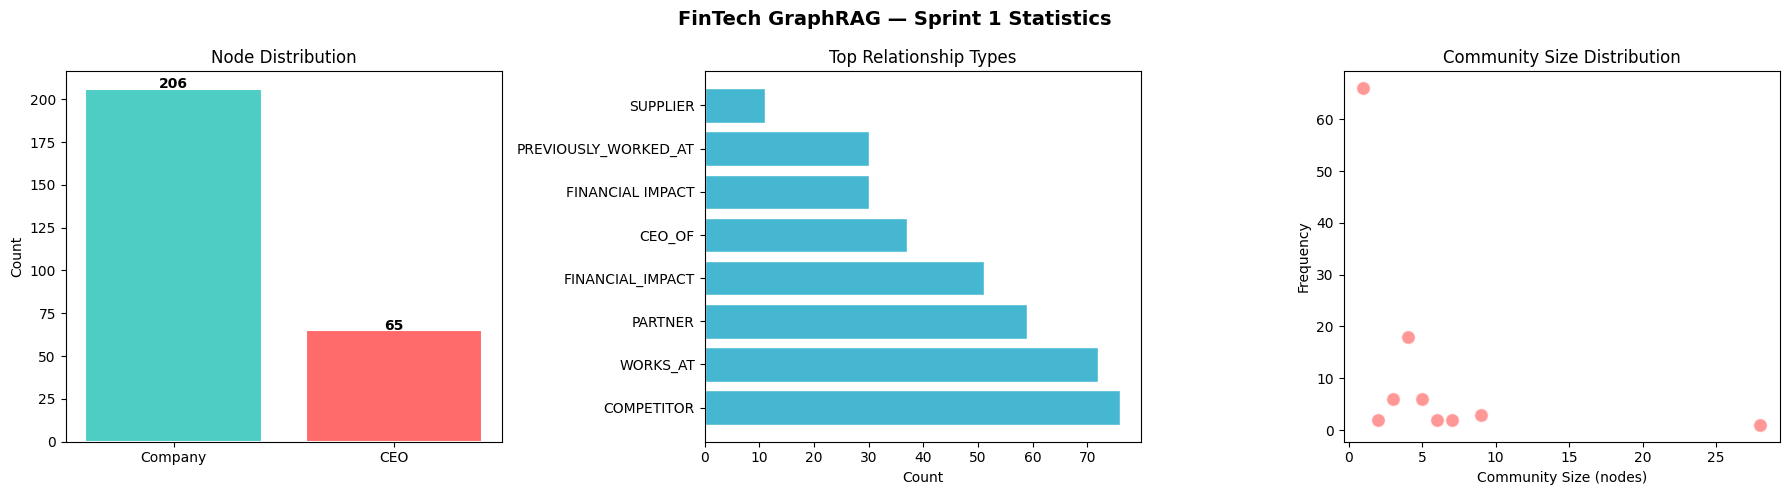

✅ Stats visualization saved as 'graphrag_stats.png'


In [37]:
# ─── Chart 1: Node Distribution ───

node_stats = db.run_query("""
    MATCH (n)
    RETURN labels(n)[0] AS label, count(n) AS count
    ORDER BY count DESC
""")

labels = [r['label'] for r in node_stats]
counts = [r['count'] for r in node_stats]
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FinTech GraphRAG — Sprint 1 Statistics', fontsize=14, fontweight='bold')

# ── Plot 1: Node Types ──
axes[0].bar(labels, counts, color=colors[:len(labels)], edgecolor='white', linewidth=1.5)
axes[0].set_title('Node Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# ── Plot 2: Relationship Types ──
rel_stats = db.run_query("""
    MATCH ()-[r]->()
    RETURN type(r) AS rel_type, count(r) AS count
    ORDER BY count DESC
    LIMIT 8
""")
rel_labels = [r['rel_type'] for r in rel_stats]
rel_counts = [r['count'] for r in rel_stats]

axes[1].barh(rel_labels, rel_counts, color='#45B7D1', edgecolor='white')
axes[1].set_title('Top Relationship Types')
axes[1].set_xlabel('Count')

# ── Plot 3: Community Size Distribution ──
comm_sizes = db.run_query("""
    MATCH (n)
    WHERE n.community IS NOT NULL
    WITH n.community[0] AS comm_id, count(n) AS size
    RETURN size, count(comm_id) AS freq
    ORDER BY size
""")
sizes = [r['size'] for r in comm_sizes]
freqs = [r['freq'] for r in comm_sizes]

axes[2].scatter(sizes, freqs, color='#FF6B6B', s=100, alpha=0.7, edgecolors='white')
axes[2].set_title('Community Size Distribution')
axes[2].set_xlabel('Community Size (nodes)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('graphrag_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Stats visualization saved as 'graphrag_stats.png'")

/tmp/ipykernel_1292/1129420596.py:60: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1292/1129420596.py:60: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1292/1129420596.py:60: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1292/1129420596.py:60: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1292/1129420596.py:61: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig('graphrag_architecture.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_1292/1129420596.py:61: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig('graphrag_architecture.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_1292

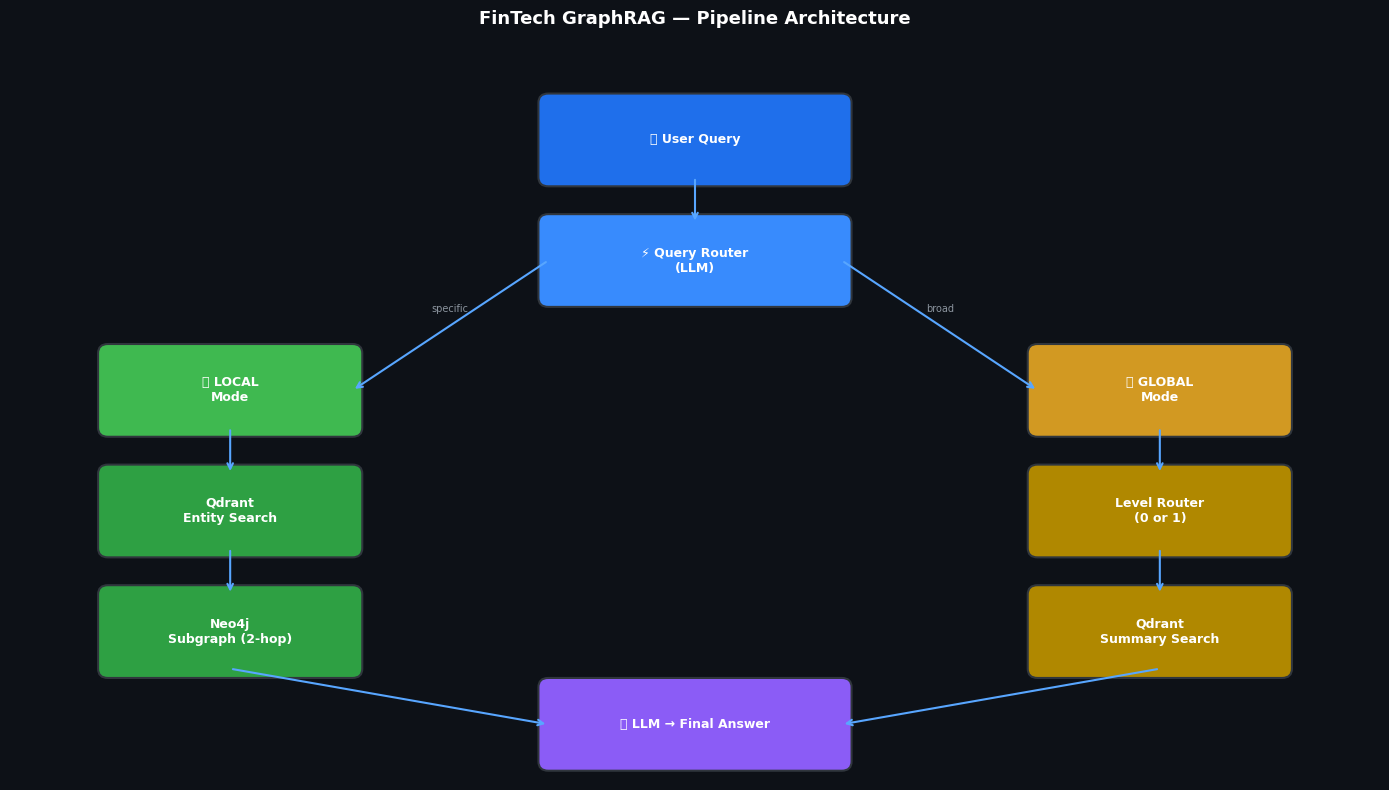

✅ Architecture diagram saved as 'graphrag_architecture.png'


In [38]:
# ─── Chart 2: Pipeline Architecture Diagram ───

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

def draw_box(ax, x, y, w, h, text, color, fontcolor='white', fontsize=9):
    box = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.1",
        facecolor=color, edgecolor='#30363d', linewidth=1.5
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            color=fontcolor, fontsize=fontsize, fontweight='bold',
            wrap=True, multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#58a6ff'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.15, label, ha='center', color='#8b949e', fontsize=7)

# Query box
draw_box(ax, 5.5, 6.5, 3, 0.8, '🔍 User Query', '#1f6feb')
# Router
draw_box(ax, 5.5, 5.2, 3, 0.8, '⚡ Query Router\n(LLM)', '#388bfd')
draw_arrow(ax, 7, 6.5, 7, 6.0, '')

# LOCAL branch
draw_box(ax, 1, 3.8, 2.5, 0.8, '📍 LOCAL\nMode', '#3fb950')
draw_box(ax, 1, 2.5, 2.5, 0.8, 'Qdrant\nEntity Search', '#2ea043')
draw_box(ax, 1, 1.2, 2.5, 0.8, 'Neo4j\nSubgraph (2-hop)', '#2ea043')

# GLOBAL branch
draw_box(ax, 10.5, 3.8, 2.5, 0.8, '🌍 GLOBAL\nMode', '#d29922')
draw_box(ax, 10.5, 2.5, 2.5, 0.8, 'Level Router\n(0 or 1)', '#b08800')
draw_box(ax, 10.5, 1.2, 2.5, 0.8, 'Qdrant\nSummary Search', '#b08800')

# LLM Answer
draw_box(ax, 5.5, 0.2, 3, 0.8, '🤖 LLM → Final Answer', '#8b5cf6')

# Arrows
draw_arrow(ax, 5.5, 5.6, 3.5, 4.2, 'specific')
draw_arrow(ax, 8.5, 5.6, 10.5, 4.2, 'broad')
draw_arrow(ax, 2.25, 3.8, 2.25, 3.3)
draw_arrow(ax, 2.25, 2.5, 2.25, 2.0)
draw_arrow(ax, 11.75, 3.8, 11.75, 3.3)
draw_arrow(ax, 11.75, 2.5, 11.75, 2.0)
draw_arrow(ax, 2.25, 1.2, 5.5, 0.6)
draw_arrow(ax, 11.75, 1.2, 8.5, 0.6)

ax.set_title('FinTech GraphRAG — Pipeline Architecture', color='white',
             fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('graphrag_architecture.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Architecture diagram saved as 'graphrag_architecture.png'")

In [39]:
# ─── Final Summary ───

print("\n" + "=" * 60)
print("✅ SPRINT 1 COMPLETE — FinTech GraphRAG Pipeline")
print("=" * 60)

nodes_total = db.run_query("MATCH (n) RETURN count(n) AS c")[0]['c']
rels_total  = db.run_query("MATCH ()-[r]->() RETURN count(r) AS c")[0]['c']

print(f"""
📊 Final Stats:
   Neo4j Nodes:         {nodes_total}
   Neo4j Relationships: {rels_total}
   Qdrant Entities:     {qdrant_client.count(COLLECTION_ENTITIES).count}
   Qdrant Summaries:    {qdrant_client.count(COLLECTION_SUMMARIES).count}
   Level 0 Communities: {len(all_summaries_level0)}
   Level 1 Communities: {len(level1_summaries)}

🏗️ Architecture:
   ✅ Query Router (LOCAL / GLOBAL)
   ✅ Entity Embeddings → Qdrant
   ✅ Qdrant → Neo4j ID Bridge
   ✅ Multi-hop Subgraph Retrieval (1..2 hops)
   ✅ Hierarchical Community Summaries (L0 + L1)
   ✅ Level-filtered Summary Search
""")


✅ SPRINT 1 COMPLETE — FinTech GraphRAG Pipeline

📊 Final Stats:
   Neo4j Nodes:         271
   Neo4j Relationships: 390
   Qdrant Entities:     271
   Qdrant Summaries:    68
   Level 0 Communities: 40
   Level 1 Communities: 28

🏗️ Architecture:
   ✅ Query Router (LOCAL / GLOBAL)
   ✅ Entity Embeddings → Qdrant
   ✅ Qdrant → Neo4j ID Bridge
   ✅ Multi-hop Subgraph Retrieval (1..2 hops)
   ✅ Hierarchical Community Summaries (L0 + L1)
   ✅ Level-filtered Summary Search

